# Komplettlauf: die verkettete End-to-End-Pipeline

Dieses Notebook wertet den **Full Run** aus – die zusammenhängende \ac{ETL}-Strecke,
bei der jedes Modell alle neun Schritte nacheinander durchläuft und die Ausgabe eines
Schritts die Eingabe des nächsten ist (`scripts/run_pipeline.py`).

Der Unterschied zu den drei Kategorie-Notebooks ist entscheidend: Dort bekommt **jede
Aufgabe die rohen, dreckigen Daten** und wird unabhängig bewertet. Hier arbeitet jeder
Schritt auf dem Ergebnis seiner Vorgänger. Damit werden zwei Effekte messbar, die die
unabhängigen Läufe nicht zeigen können:

- **Vorbereitung:** Spätere Schritte profitieren von bereits normalisierten Daten
  (die Schlüssel-Deduplizierung kann nach ISO-Datumsformat sauber sortieren).
- **Fehlerfortpflanzung und Kaskaden-Abbruch:** Eine kleine Abweichung in einem frühen
  Schritt pflanzt sich fort; ein Absturz blockiert alle abhängigen Folgeschritte.

Als fünfter Teilnehmer läuft die **regelbasierte Baseline** dieselbe Kette
(`python scripts/run_pipeline.py --providers baseline`). Sie nutzt für die
formalisierbaren Schritte dieselben deterministischen Routinen wie die Referenz und
für die beiden semantischen Schritte ihre begrenzten Heuristiken – dadurch wird
sichtbar, wie sich deren Schwächen in der Kette fortpflanzen.

Kennzahl ist wie überall die **abgeglichene Genauigkeit**, gemessen gegen eine
*verkettete Referenz*: dieselbe Schrittfolge, ausgeführt mit den regelbasierten
Referenzfunktionen. Je Schritt sind bis zu drei Versuche erlaubt (Retry nach Absturz
oder unvollständigem Schema).

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reporting import pipeline_analysis as pa
from reporting import compare
from reporting.analysis import PROVIDER_LABEL, load_runs
from experiments.pipeline_runner import PIPELINE

seed = 1
pipe = pa.load_pipeline(seed)
PROVS = [p for p in pa.PIPE_ORDER if p in set(pipe.provider)]  # Modelle + regelbasierte Baseline
LABELS = [PROVIDER_LABEL[p] for p in PROVS]
STEPS = [s.name for s in PIPELINE]
STEP_LABELS = [s.label for s in PIPELINE]

print(f"Seed {seed}: {len(PROVS)} Teilnehmer x {len(STEPS)} Schritte = {len(pipe)} Schritt-Laeufe")
print(f"Grafiken werden gespeichert unter: {compare.FIG_DIR}")
pipe.head()

Seed 1: 5 Teilnehmer x 9 Schritte = 45 Schritt-Laeufe
Grafiken werden gespeichert unter: C:\Users\geige\Desktop\DHBW\Bachelorarbeit\project\figures


,provider,label,step,step_label,order,status,accuracy,attempts,error,duration_s,llm_s,exec_s,cost_usd,prompt_tokens,completion_tokens,row_actual,row_expected,model
0,anthropic,Claude,cleaning_easy,1 · Bereinigung: Leerzeichen & fehlende Werte,0,ok,1.000000,1,NaN,5.03,4.06,0.94,0.005700,550,270,540.0,540.0,claude-sonnet-5
1,anthropic,Claude,cleaning_medium,2 · Bereinigung: Datumsformate,1,ok,1.000000,1,NaN,16.96,15.87,1.06,0.021102,569,1293,540.0,540.0,claude-sonnet-5
2,anthropic,Claude,cleaning_hard,3 · Bereinigung: Ländercodes (ISO),2,ok,0.987778,1,NaN,29.86,28.80,1.03,0.061176,607,3957,540.0,540.0,claude-sonnet-5
3,anthropic,Claude,dedup_easy,4 · Deduplizierung: exakte Duplikate,3,ok,0.984135,1,NaN,4.99,3.97,0.96,0.004182,504,178,520.0,520.0,claude-sonnet-5
4,anthropic,Claude,dedup_medium,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),4,ok,0.979086,1,NaN,4.34,3.26,1.05,0.005526,542,260,514.0,514.0,claude-sonnet-5


## 1 · Verlauf der Pipeline auf einen Blick

Zeilen = Schritte (von oben nach unten der Datenfluss), Spalten = Modelle. Grüne Felder
zeigen die Genauigkeit des Schritts, rote den Abbruch, graue die dadurch blockierten
Folgeschritte (`figures/pipeline_verlauf.png`).

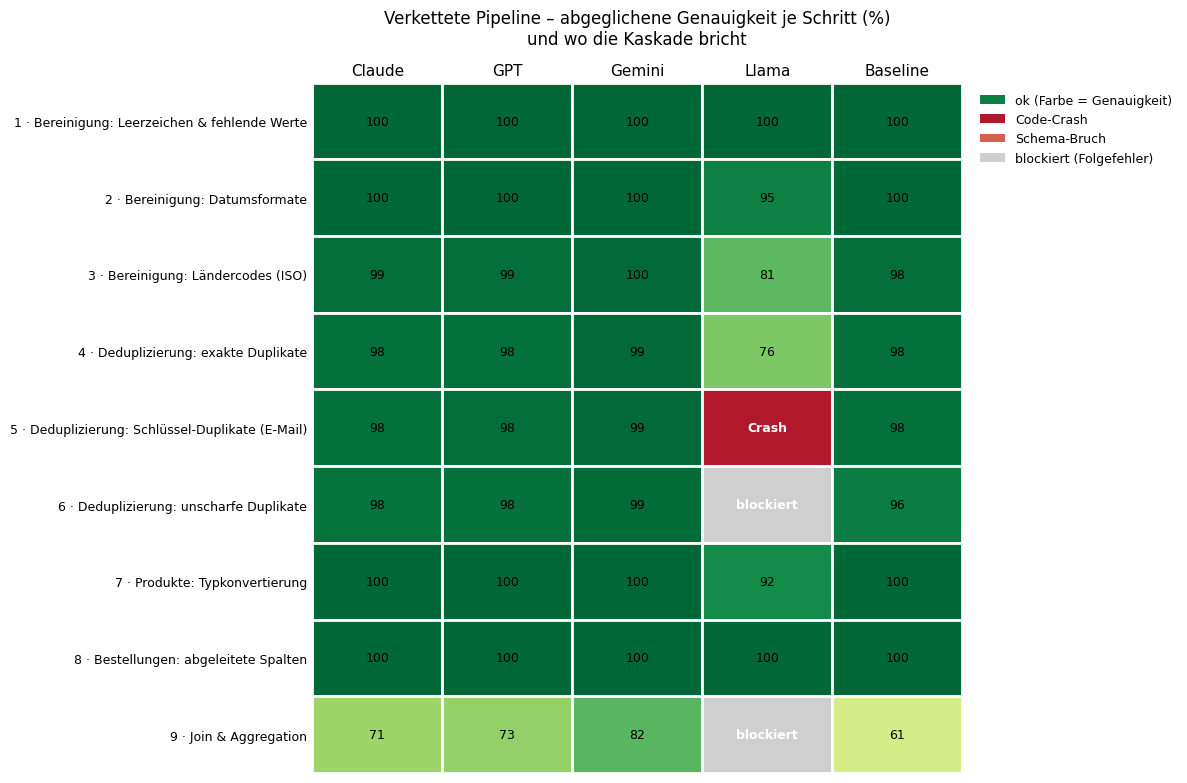

In [2]:
fig, _ = pa.pipeline_heatmap(seed); plt.show()

## 2 · Zusammenfassung je Modell

Wie weit kommt jedes Modell, wo bricht die Kette, und mit welcher Endgenauigkeit
schließt der letzte Schritt ab?

,Schritte ok,Ende erreicht,Endgenauigkeit,Erster Abbruch
Modell,,,,
Claude,9/9,ja,71.2%,—
GPT,9/9,ja,72.7%,—
Gemini,9/9,ja,81.8%,—
Llama,6/9,nein,—,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail)
Baseline,9/9,ja,60.6%,—


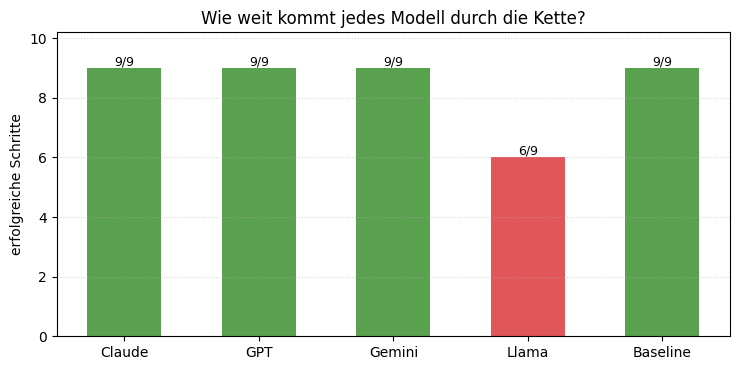

In [3]:
summary = pa.pipeline_summary(seed)
display(summary)

ok_steps = [int((pipe[pipe.provider == p].status == "ok").sum()) for p in PROVS]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar(LABELS, ok_steps, 0.55,
              color=["#59a14f" if n == len(STEPS) else "#e15759" for n in ok_steps])
for r, n in zip(bars, ok_steps):
    ax.text(r.get_x() + r.get_width() / 2, n, f"{n}/{len(STEPS)}", ha="center",
            va="bottom", fontsize=9)
ax.set_ylim(0, len(STEPS) + 1.2)
ax.set_ylabel("erfolgreiche Schritte")
ax.set_title("Wie weit kommt jedes Modell durch die Kette?")
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "pipeline_schritte_ok"); plt.show()

## 3 · Genauigkeit entlang der Schrittfolge

Der Verlauf zeigt, ob die Qualität über die Kette hinweg stabil bleibt. Ein `x` markiert
den Abbruch eines Modells, eine Lücke die dadurch blockierten Schritte
(`figures/pipeline_genauigkeit.png`).

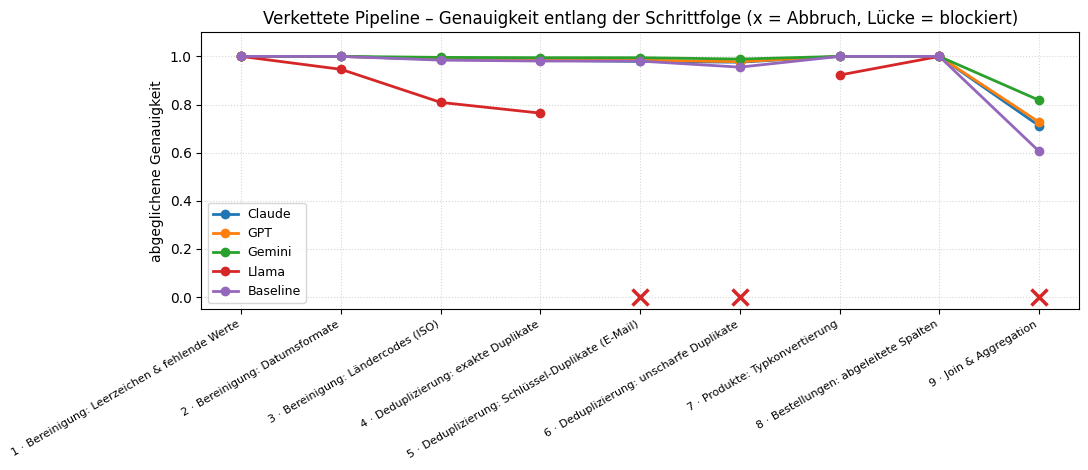

,Claude,GPT,Gemini,Llama,Baseline
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,100.0,100.0,100.0
2 · Bereinigung: Datumsformate,100.0,100.0,100.0,94.6,100.0
3 · Bereinigung: Ländercodes (ISO),98.8,98.8,99.6,80.9,98.4
4 · Deduplizierung: exakte Duplikate,98.4,98.4,99.5,76.4,98.1
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),97.9,98.4,99.5,NaN,98.1
6 · Deduplizierung: unscharfe Duplikate,97.6,97.8,98.9,NaN,95.5
7 · Produkte: Typkonvertierung,100.0,100.0,100.0,92.2,100.0
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,100.0,100.0,100.0
9 · Join & Aggregation,71.2,72.7,81.8,NaN,60.6


In [4]:
fig, _ = pa.step_accuracy(seed); plt.show()

acc_tab = pipe.pivot_table(index="step", columns="provider", values="accuracy",
                           aggfunc="first").reindex(STEPS)
acc_tab = acc_tab[[p for p in PROVS if p in acc_tab.columns]]
acc_tab.index = STEP_LABELS
acc_tab.columns = [PROVIDER_LABEL[c] for c in acc_tab.columns]
status_tab = pipe.pivot_table(index="step", columns="provider", values="status",
                              aggfunc="first").reindex(STEPS)
status_tab.index = STEP_LABELS
display((acc_tab * 100).round(1))

## 4 · Aufwand: Kosten und Versuche

Die Pipeline ist deutlich günstiger als die vollständige Matrix, weil jedes Modell jeden
Schritt nur einmal (plus ggf. Retries) ausführt. Rechts wird sichtbar, wo ein Modell
Nachbesserungsversuche gebraucht hat (`figures/pipeline_aufwand.png`).

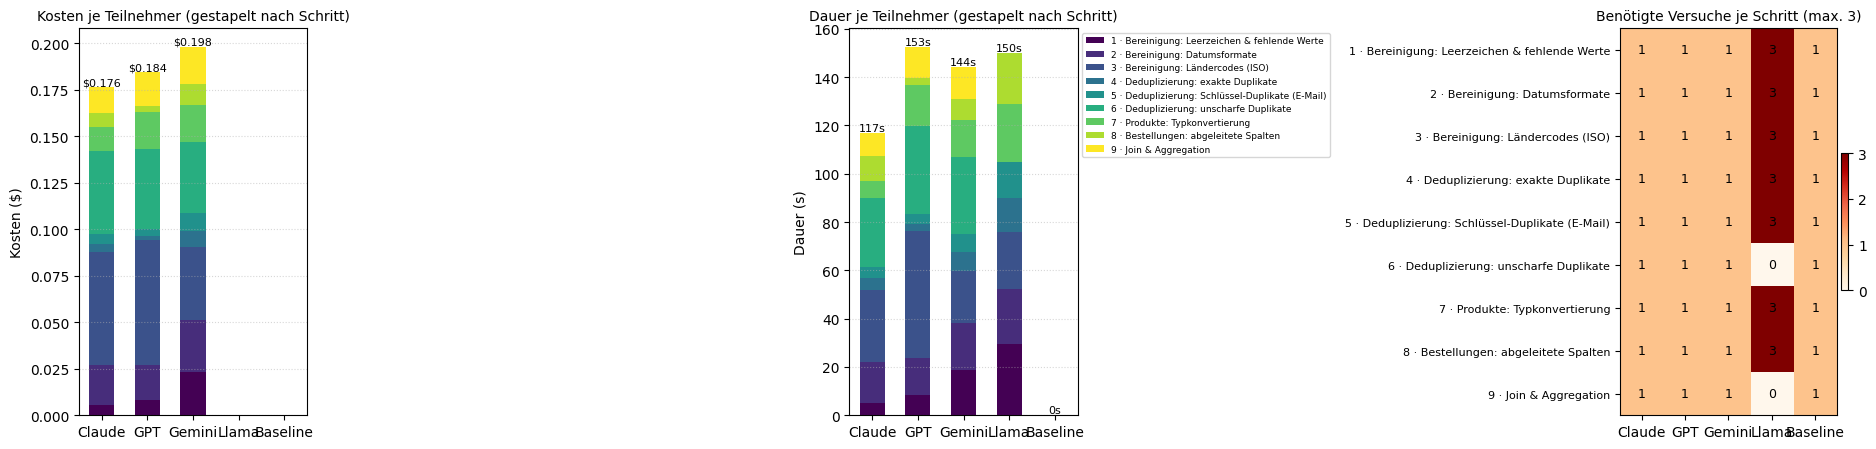

,kosten,dauer_s,modellzeit_s,skriptzeit_s,tok_in,tok_out,versuche,schritte_ok,Kosten je ok-Schritt
Claude,0.1764,116.90,107.62,9.00,5500,10657,9,9,0.0196
GPT,0.1844,152.54,143.13,9.09,3480,11715,9,9,0.0205
Gemini,0.1982,144.13,133.14,10.70,3763,25668,9,9,0.0220
Llama,0.0000,149.80,133.93,15.19,7671,4636,21,6,0.0000
Baseline,0.0000,0.17,0.00,0.17,0,0,9,9,0.0000


In [5]:
fig, _ = pa.effort(seed); plt.show()

kosten = (pipe.groupby("provider")
          .agg(kosten=("cost_usd", "sum"), dauer_s=("duration_s", "sum"),
               modellzeit_s=("llm_s", "sum"), skriptzeit_s=("exec_s", "sum"),
               tok_in=("prompt_tokens", "sum"),
               tok_out=("completion_tokens", "sum"), versuche=("attempts", "sum"),
               schritte_ok=("status", lambda s: int((s == "ok").sum())))
          .reindex(PROVS))
kosten.index = LABELS
kosten["Kosten je ok-Schritt"] = (kosten.kosten / kosten.schritte_ok).round(4)
kosten.round(4)

Dauer je Schritt in Sekunden. Der Löwenanteil ist die Antwortzeit des Modells – das
erzeugte pandas-Skript selbst läuft in Bruchteilen einer Sekunde, und die
regelbasierte Baseline durchläuft die komplette Kette in unter einer Zehntelsekunde.
Läufe, die vor Einführung der Zeitmessung entstanden sind, erscheinen als `NaN`.


In [6]:
pa.step_durations(seed)


,davon Modell (Ø),davon Skript (Ø),Claude,GPT,Gemini,Llama,Baseline
1 · Bereinigung: Leerzeichen & fehlende Werte,14.16,1.24,5.03,8.40,18.93,29.40,0.03
2 · Bereinigung: Datumsformate,17.31,1.33,16.96,15.34,19.38,23.07,0.02
3 · Bereinigung: Ländercodes (ISO),30.53,1.32,29.86,52.68,21.60,23.43,0.02
4 · Deduplizierung: exakte Duplikate,5.96,1.28,4.99,2.70,7.82,13.89,0.01
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),6.31,1.32,4.34,4.05,7.33,14.92,0.02
6 · Deduplizierung: unscharfe Duplikate,23.10,1.19,28.82,36.62,31.80,0.00,0.02
7 · Produkte: Typkonvertierung,14.55,1.25,6.82,16.94,15.31,24.26,0.01
8 · Bestellungen: abgeleitete Spalten,9.36,1.27,10.38,2.88,8.62,20.83,0.02
9 · Join & Aggregation,8.19,0.78,9.70,12.93,13.34,0.00,0.02


## 5 · Verkettete Pipeline gegen unabhängige Einzelläufe

Dieselbe Aufgabe einmal in der Kette (auf vorbereiteten Daten) und einmal als
unabhängiger Einzellauf auf den Rohdaten – jeweils gemittelt über die Modelle. Für den
Einzellauf wird die **beste klassische Prompt-Strategie** herangezogen, also der faire
Bestfall (`figures/pipeline_vs_einzellauf.png`).

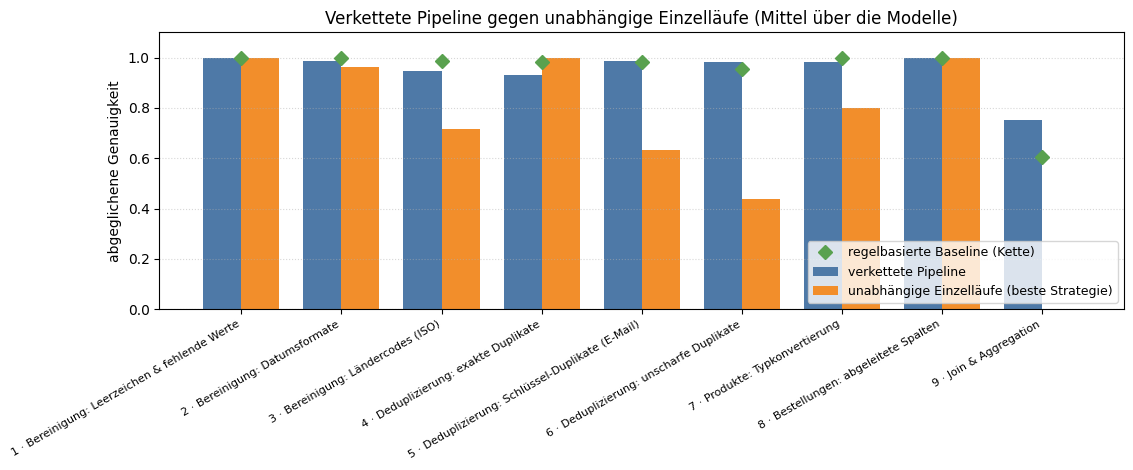

,Pipeline (Ø Modelle),"Einzellauf (beste Strategie, Ø Modelle)",Baseline (Kette),Differenz
Schritt,,,,
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,100.0,0.0
2 · Bereinigung: Datumsformate,98.7,96.4,100.0,2.3
3 · Bereinigung: Ländercodes (ISO),94.5,71.5,98.4,23.0
4 · Deduplizierung: exakte Duplikate,93.2,100.0,98.1,-6.8
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),98.6,63.3,98.1,35.3
6 · Deduplizierung: unscharfe Duplikate,98.1,43.8,95.5,54.3
7 · Produkte: Typkonvertierung,98.1,80.1,100.0,17.9
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,100.0,0.0
9 · Join & Aggregation,75.3,0.1,60.6,75.2


In [7]:
runs = load_runs(seed=seed, include_baseline=True)
fig, T = pa.pipeline_vs_matrix(runs, seed); plt.show()
(T * 100).round(1)

## 6 · Fehlerfortpflanzung im Endschritt

Der Endschritt (Join & Aggregation) fällt bei allen Modellen deutlich ab, obwohl Schema
und Zeilenzahl stimmen und die Gruppierungsschlüssel vollständig getroffen werden. Die
Ursache liegt **nicht** im Endschritt selbst: Weil die Deduplizierung stromaufwärts
andere Kundenzeilen entfernt als die Referenz, fallen beim Join andere Bestellungen
heraus – und jede betroffene Gruppe zählt in Umsatz *und* Bestellanzahl als falsch.

In [8]:
diag = pa.final_step_diagnosis(seed)
display(diag)

,Zeilen Ist,Zeilen Soll,Schluessel-Treffer,total_revenue_eur korrekt,order_count korrekt
Modell,,,,,
Claude,66,66,66/66,71.2,71.2
GPT,66,66,66/66,72.7,72.7
Gemini,66,66,66/66,81.8,81.8
Baseline,66,66,66/66,60.6,60.6


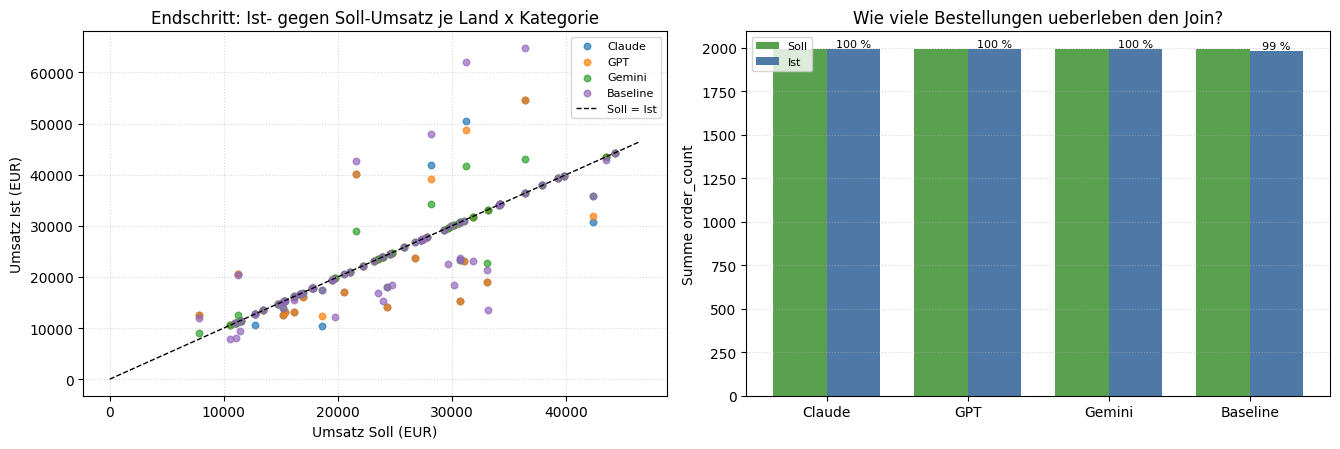

,Bestellungen Soll,Bestellungen Ist,Umsatz Soll,Umsatz Ist,Gruppen exakt %
Modell,,,,,
Claude,1995,1992,1605337.12,1604450.44,71.2
GPT,1995,1995,1605337.12,1605337.12,72.7
Gemini,1995,1995,1605337.12,1605337.12,81.8
Baseline,1995,1980,1605337.12,1591870.61,60.6


In [9]:
from experiments.pipeline_runner import build_chain_reference
exp = build_chain_reference(seed)["final"]
keys = ["country_code", "category"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
rows = []
for i, prov in enumerate(PROVS):
    p = pa.PIPELINE_RESULTS / str(seed) / prov / "final" / "output.parquet"
    if not p.exists():
        continue
    act = pd.read_parquet(p)[exp.columns]
    m = exp.merge(act, on=keys, suffixes=("_soll", "_ist"))
    axes[0].scatter(m.total_revenue_eur_soll, m.total_revenue_eur_ist, s=22,
                    alpha=0.7, color=f"C{i}", label=PROVIDER_LABEL[prov])
    rows.append({"Modell": PROVIDER_LABEL[prov],
                 "Bestellungen Soll": int(m.order_count_soll.sum()),
                 "Bestellungen Ist": int(m.order_count_ist.sum()),
                 "Umsatz Soll": round(float(m.total_revenue_eur_soll.sum()), 2),
                 "Umsatz Ist": round(float(m.total_revenue_eur_ist.sum()), 2),
                 "Gruppen exakt %": round(float((m.total_revenue_eur_soll
                                                 - m.total_revenue_eur_ist).abs().le(0.01).mean()) * 100, 1)})
lim = float(exp.total_revenue_eur.max()) * 1.05
axes[0].plot([0, lim], [0, lim], "k--", lw=1, label="Soll = Ist")
axes[0].set_xlabel("Umsatz Soll (EUR)")
axes[0].set_ylabel("Umsatz Ist (EUR)")
axes[0].set_title("Endschritt: Ist- gegen Soll-Umsatz je Land x Kategorie")
axes[0].legend(fontsize=8)
axes[0].grid(ls=":", alpha=0.5)

V = pd.DataFrame(rows).set_index("Modell")
x = np.arange(len(V))
axes[1].bar(x - 0.19, V["Bestellungen Soll"], 0.38, color="#59a14f", label="Soll")
axes[1].bar(x + 0.19, V["Bestellungen Ist"], 0.38, color="#4e79a7", label="Ist")
for i, (s, a) in enumerate(zip(V["Bestellungen Soll"], V["Bestellungen Ist"])):
    axes[1].text(i + 0.19, a, f"{a / s * 100:.0f} %", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(V.index)
axes[1].set_ylabel("Summe order_count")
axes[1].set_title("Wie viele Bestellungen ueberleben den Join?")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "pipeline_fehlerfortpflanzung"); plt.show()
display(V)

In [10]:
# Woher kommt die Abweichung? Zeilenzahlen der Kundentabelle entlang der Kette.
chain = build_chain_reference(seed)
rowtab = pipe[pipe.step.isin(STEPS)].pivot_table(
    index="step", columns="provider", values="row_actual", aggfunc="first").reindex(STEPS)
rowtab = rowtab[[p for p in PROVS if p in rowtab.columns]]
rowtab.columns = [PROVIDER_LABEL[c] for c in rowtab.columns]
rowtab.insert(0, "Soll", [len(chain[s]) for s in STEPS])
rowtab.index = STEP_LABELS
rowtab

,Soll,Claude,GPT,Gemini,Llama,Baseline
1 · Bereinigung: Leerzeichen & fehlende Werte,540,540.0,540.0,540.0,540.0,540.0
2 · Bereinigung: Datumsformate,540,540.0,540.0,540.0,540.0,540.0
3 · Bereinigung: Ländercodes (ISO),540,540.0,540.0,540.0,540.0,540.0
4 · Deduplizierung: exakte Duplikate,520,520.0,520.0,520.0,520.0,520.0
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),514,514.0,514.0,514.0,NaN,514.0
6 · Deduplizierung: unscharfe Duplikate,497,500.0,501.0,500.0,NaN,505.0
7 · Produkte: Typkonvertierung,100,100.0,100.0,100.0,100.0,100.0
8 · Bestellungen: abgeleitete Spalten,2000,2000.0,2000.0,2000.0,2000.0,2000.0
9 · Join & Aggregation,66,66.0,66.0,66.0,NaN,66.0


## 7 · Abbrüche im Detail

Für jeden nicht erfolgreichen Schritt die protokollierte Ursache. Das lokale Modell
scheitert bereits am ersten Schritt und blockiert damit die gesamte Kundenstrecke; die
beiden von den Rohdaten gespeisten Nebenstränge (Produkte, Bestellungen) laufen trotzdem
durch.

In [11]:
fehler = pipe[pipe.status != "ok"].copy()
if len(fehler):
    fehler["Modell"] = fehler.provider.map(PROVIDER_LABEL)
    fehler["Fehler (gekuerzt)"] = fehler.error.fillna("").str.replace(r"\s+", " ", regex=True).str[:180]
    display(fehler[["Modell", "step_label", "status", "attempts", "Fehler (gekuerzt)"]]
            .reset_index(drop=True))
    for _, r in fehler[fehler.status == "code_error"].iterrows():
        print(f"\n--- {PROVIDER_LABEL[r.provider]} | {r.step_label} "
              f"(nach {r.attempts} Versuchen)\n{r.error}")
else:
    print("Kein Schritt abgebrochen.")

,Modell,step_label,status,attempts,Fehler (gekuerzt)
0,Llama,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),code_error,3,"Code-Ausführung fehlgeschlagen: le ""pandas/_li..."
1,Llama,6 · Deduplizierung: unscharfe Duplikate,blocked,0,Vorheriger Schritt fehlgeschlagen
2,Llama,9 · Join & Aggregation,blocked,0,Vorheriger Schritt fehlgeschlagen



--- Llama | 5 · Deduplizierung: Schlüssel-Duplikate (E-Mail) (nach 3 Versuchen)
Code-Ausführung fehlgeschlagen: le "pandas/_libs/tslibs/conversion.pyx", line 658, in pandas._libs.tslibs.conversion.convert_str_to_tsobject
  File "pandas/_libs/tslibs/parsing.pyx", line 321, in pandas._libs.tslibs.parsing.parse_datetime_string
  File "pandas/_libs/tslibs/parsing.pyx", line 674, in pandas._libs.tslibs.parsing.dateutil_parse
pandas._libs.tslibs.parsing.DateParseError: year 1639353600 is out of range: 1639353600



Der Beleg dafür steckt im dritten Schritt: Wer dort mehr Länder auf `UNKNOWN`
zurückfallen lässt, verschiebt die betroffenen Kunden im Endschritt in die falsche
Ländergruppe – und zwar in *jeder* Kennzahl gleichzeitig.

Die Zerlegung trennt die drei möglichen Ursachen: Ist die Aggregation selbst falsch,
kostet die Wahl des Duplikat-Repräsentanten, oder sind es die Ländercodes? Spalte 1
wendet die Referenzlogik auf **dieselben Zwischenstände** an – ein Wert von 1,0 heißt,
dass der Endschritt fehlerfrei rechnet und der gesamte Fehler geerbt ist.


In [12]:
pa.final_step_decomposition(seed)


,eigener Code korrekt,nur Dedup-Effekt,Endergebnis,verwaiste Bestellungen
Teilnehmer,,,,
Claude,1.0,0.924,0.712,8
GPT,1.0,1.000,0.727,5
Gemini,1.0,1.000,0.818,5
Baseline,1.0,0.833,0.606,20


In [13]:
# Beleg fuer die Ursache: wie viele Kunden bekommen im 3. Schritt den falschen Laendercode?
# Achtung: 20 customer_id kommen doppelt vor (Fuzzy-Zwillinge tragen eine eigene ID, exakte
# Duplikate teilen sie) -- ein Merge auf customer_id wuerde die Zeilen aufblaehen. Der Schritt
# erhaelt Zeilenzahl und -reihenfolge, deshalb wird positionsweise verglichen.
e = chain["cleaning_hard"]
rows = []
ok_provs = [p for p in PROVS if not pipe[(pipe.provider == p) & (pipe.step == "cleaning_hard")
                                          & (pipe.status == "ok")].empty]
for prov in ok_provs:  # nur Modelle, die den Schritt in diesem Lauf bestanden haben
    a = pd.read_parquet(pa.PIPELINE_RESULTS / str(seed) / prov / "cleaning_hard" / "output.parquet")
    if len(a) != len(e) or a.customer_id.astype(str).tolist() != e.customer_id.astype(str).tolist():
        rows.append({"Modell": PROVIDER_LABEL[prov], "Hinweis": "Zeilenreihenfolge abweichend"})
        continue
    bad = a.country.astype(str).values != e.country.astype(str).values
    roh = pd.read_parquet(pa.PIPELINE_RESULTS / str(seed) / prov / "cleaning_medium" / "output.parquet")
    rows.append({
        "Modell": PROVIDER_LABEL[prov],
        "falsche Laendercodes": int(bad.sum()),
        "Anteil %": round(float(bad.mean()) * 100, 1),
        "davon UNKNOWN": int((a.country.astype(str).values[bad] == "UNKNOWN").sum()),
        "nicht erkannte Schreibweisen": ", ".join(
            f"{k} ({v})" for k, v in roh.country.astype(str).values[bad].tolist()
            and pd.Series(roh.country.astype(str).values[bad]).value_counts().head(5).items()),
    })
pd.DataFrame(rows).set_index("Modell")

,falsche Laendercodes,Anteil %,davon UNKNOWN,nicht erkannte Schreibweisen
Modell,,,,
Claude,33,6.1,33,"SUI (14), Deutshcland (11), GER (8)"
GPT,33,6.1,33,"SUI (14), Deutshcland (11), GER (8)"
Gemini,11,2.0,11,Deutshcland (11)
Llama,371,68.7,363,"France (22), Polen (19), Poland (19), England ..."
Baseline,42,7.8,42,"England (17), Holland (14), Deutshcland (11)"


## 8 · Fehlerfortpflanzung isolieren

Bis hierhin lässt sich nicht trennen, ob ein schwaches Schritt-Ergebnis am Modell liegt
oder an dem, was die Vorgängerschritte hinterlassen haben. Dafür gibt es einen zweiten
Lauf: `python scripts/run_pipeline.py --inputs reference`. Dort bekommt **jeder Schritt
die Soll-Ausgabe seines Vorgängers** aus der Kettenreferenz statt der eigenen. Die
Aufgabe bleibt identisch, nur die Eingabe ist sauber.

Damit liegt die Obergrenze für alle Modelle bei 1,0, und die Rechnung wird eindeutig:

> **verkettet − isoliert = Preis der Fehlerfortpflanzung**

Wichtig: Die Referenz liefert nur saubere *Eingabedaten*, nicht die Lösung des jeweiligen
Schritts — wie E-Mail-Duplikate zu entfernen sind, steht in einem korrekt normalisierten
Datumsfeld nicht drin. Die isolierten Läufe liegen unter
`data/results_pipeline/<seed>/<provider>_isolated/`.

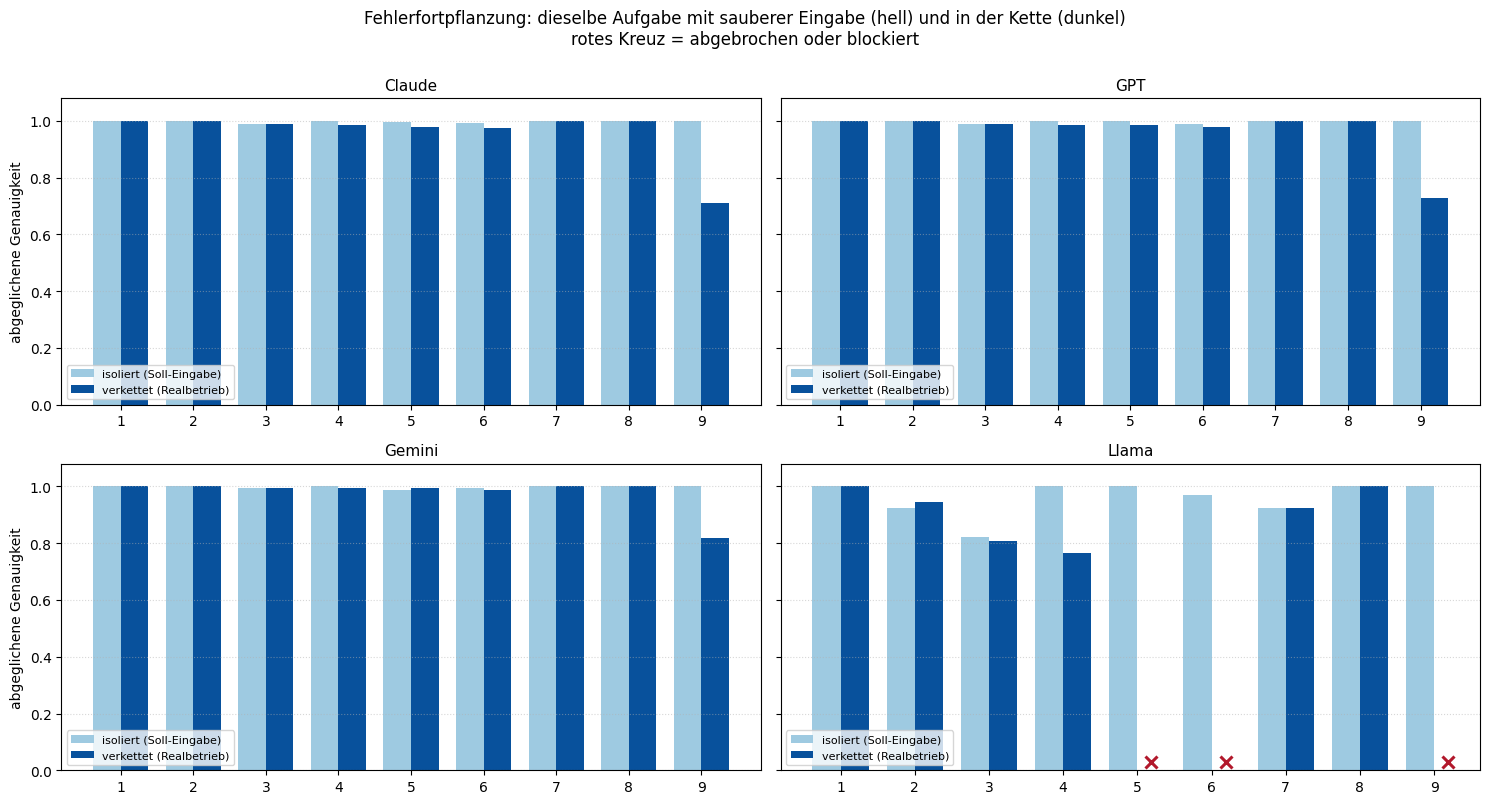

In [14]:
fig = pa.propagation_plot(seed); plt.show()

Dieselben Zahlen als Tabelle (in %), je Modell isolierte Leistung, verkettetes Ergebnis
und die Differenz. Leere Felder sind Schritte, die im jeweiligen Modus abgebrochen oder
blockiert waren.

In [15]:
prop = pa.propagation_table(seed)
display((prop * 100).round(1))
pa.propagation_summary(seed)

,Claude isol.,Claude verk.,Claude Diff.,GPT isol.,GPT verk.,GPT Diff.,Gemini isol.,Gemini verk.,Gemini Diff.,Llama isol.,Llama verk.,Llama Diff.
Schritt,,,,,,,,,,,,
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0
2 · Bereinigung: Datumsformate,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0,92.6,94.6,2.1
3 · Bereinigung: Ländercodes (ISO),98.8,98.8,-0.0,98.8,98.8,-0.0,99.6,99.6,0.0,82.3,80.9,-1.4
4 · Deduplizierung: exakte Duplikate,100.0,98.4,-1.6,100.0,98.4,-1.6,100.0,99.5,-0.5,100.0,76.4,-23.6
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),99.6,97.9,-1.7,100.0,98.4,-1.6,98.8,99.5,0.6,100.0,NaN,NaN
6 · Deduplizierung: unscharfe Duplikate,99.4,97.6,-1.8,99.0,97.8,-1.2,99.4,98.9,-0.5,97.2,NaN,NaN
7 · Produkte: Typkonvertierung,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0,92.2,92.2,0.0
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0
9 · Join & Aggregation,100.0,71.2,-28.8,100.0,72.7,-27.3,100.0,81.8,-18.2,100.0,NaN,NaN


,Schritte isoliert ok,Schritte verkettet ok,Genauigkeit isoliert (Ø),Genauigkeit verkettet (Ø),Endschritt isoliert,Endschritt verkettet
Modell,,,,,,
Claude,9,9,0.998,0.960,1.0,0.712
GPT,9,9,0.998,0.962,1.0,0.727
Gemini,9,9,0.998,0.977,1.0,0.818
Llama,9,6,0.960,0.907,1.0,NaN


**Ablesbar wird damit dreierlei:**

1. **Der Endschritt ist kein Modellproblem.** Alle vier Modelle lösen Join und
   Aggregation mit sauberer Eingabe fehlerfrei (1,000). Der verkettete Wert von
   0,712 bis 0,818 ist vollständig geerbt — bei Llama kommt der Schritt gar nicht
   erst zustande.
2. **Auch die Deduplizierung ist überwiegend geerbt.** Die Schritte 4 und 5 sind
   isoliert bei allen Modellen praktisch perfekt; verkettet kosten sie 1–2
   Prozentpunkte, bei Llama 23,6.
3. **Was übrig bleibt, ist die echte Modellleistung:** die semantische
   Länder-Vereinheitlichung (Schritt 3) als einziger Schritt, den auch isoliert kein
   Modell vollständig löst, sowie bei Llama zusätzlich Datumsformate und
   Typkonvertierung.

## 9 · Kernaussagen des Komplettlaufs (Seed 1)

- **Drei von vier Modellen durchlaufen die Kette vollständig.** Claude, GPT und Gemini
  erreichen 9/9 Schritte; das lokale Llama kommt auf 6/9 und scheitert in Schritt 5.
  Die regelbasierte Baseline läuft ebenfalls durch.
- **Die Kette funktioniert bis zum Endschritt sehr gut:** Schritte 1, 2, 7 und 8 sind
  bei allen Cloud-Modellen perfekt, die Schritte 3 bis 6 liegen zwischen 0,976 und
  0,996. Retries sind kaum nötig, die Kosten liegen bei 0,13–0,35 $ je Modell
  gegenüber 6,57 $ für die vollständige Aufgaben-Matrix.
- **Der Endschritt bricht ein — und zwar ausschließlich durch geerbte Fehler.** Der
  isolierte Lauf (Abschnitt 8) zeigt für alle vier Modelle 1,000 bei Join und
  Aggregation; verkettet bleiben 0,712 (Claude), 0,727 (GPT) und 0,818 (Gemini). Die
  Aggregation selbst rechnet nachweislich fehlerfrei (Spalte „eigener Code korrekt" =
  1,0), sie verstärkt nur, was stromaufwärts entstanden ist: Ein einziger falsch
  einsortierter Kunde macht zwei Gruppen in beiden Kennzahlen falsch.
- **Die verbleibende Fehlerquelle ist die Länder-Vereinheitlichung.** Sie ist der
  einzige Schritt, den auch mit perfekter Eingabe kein Modell vollständig löst
  (Gemini 0,996, Claude und GPT 0,988, Llama 0,823). Übrig bleiben Schweizer und
  deutsche Nicht-ISO-Kürzel (SUI, GER) sowie der Tippfehler „Deutshcland", an dem alle
  vier scheitern.
- **Llama versteht die Aufgaben, arbeitet aber unsauber.** Isoliert erreicht es 9/9
  Schritte mit im Mittel 0,960 und löst sogar den Endschritt perfekt. In der Kette
  bleiben davon 6/9 und 0,907, weil seine 145 nicht konvertierten Unix-Timestamps aus
  Schritt 2 drei Schritte später den Absturz auslösen. Zwei seiner drei Ausfälle sind
  geerbt, nicht eigen.
- **Die regelbasierte Baseline** ist in allen formalisierbaren Schritten perfekt und
  verliert dort, wo Weltwissen nötig ist: 57 von 540 Ländercodes fallen auf `UNKNOWN`
  (England, Holland, UK, OEsterreich, Deutshcland), im Endschritt bleiben 0,606. Sie
  liegt damit hinter allen drei Cloud-Modellen — der Kernbeleg für H1.
- **Für die Praxis:** In verketteten \ac{ETL}-Strecken entscheidet die Qualität der
  frühen, semantisch geprägten Schritte über das Endergebnis. Eine Zwischenprüfung nach
  jedem Schritt ist wirksamer als eine Endkontrolle — und wirksamer als jede weitere
  Prompt-Iteration, wie der still wirkungslose Code-Pfad in Schritt 1 gezeigt hat.